# COF-Landscaper hybrid/HPC postprocessing

Run `cof-landscaper.py` with the companion JSON configuration locally or on an HPC system before using this notebook. The driver performs construction, MACE screening, candidate optimization, analysis, and simulated PXRD generation. This notebook supports interactive inspection and PXRD-guided refinement. 

In [1]:
import coflandscaper as cl

/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [ ]:
COF_NAME = "COF-LZU-1"
MODE = "both"

### Potential Energy Landscape (PES)

The submitted cluster workflow has already generated the simplified stacking potential energy landscapes from the single-point energies of the ILD/ILS structure matrices. They can be replotted here for visualization and further inspection.

Reminder: The PES provides a reduced-dimensional representation of the relative stability of the sampled stacking arrangements as a function of interlayer distance (ILD) and interlayer slipping (ILS). Because the structures are not fully relaxed at this stage, it should be interpreted as a qualitative to semi-quantitative screening landscape rather than the complete high-dimensional potential energy surface.

Inspecting the PES can be useful for identifying additional structures that should undergo full geometry optimization beyond the automatically selected minima. If additional sampling points are desired, specify their `(ILD, ILS)` coordinates separately for the serrated and inclined stacking modes using `EXTRA_SERR` and `EXTRA_INCL` in the workflow parameter JSON file, then resubmit the cluster workflow.

For example:

```json
"EXTRA_SERR": [[3.4, 2.0], [3.5, 1.0]],
"EXTRA_INCL": [[3.3, 2.0]]

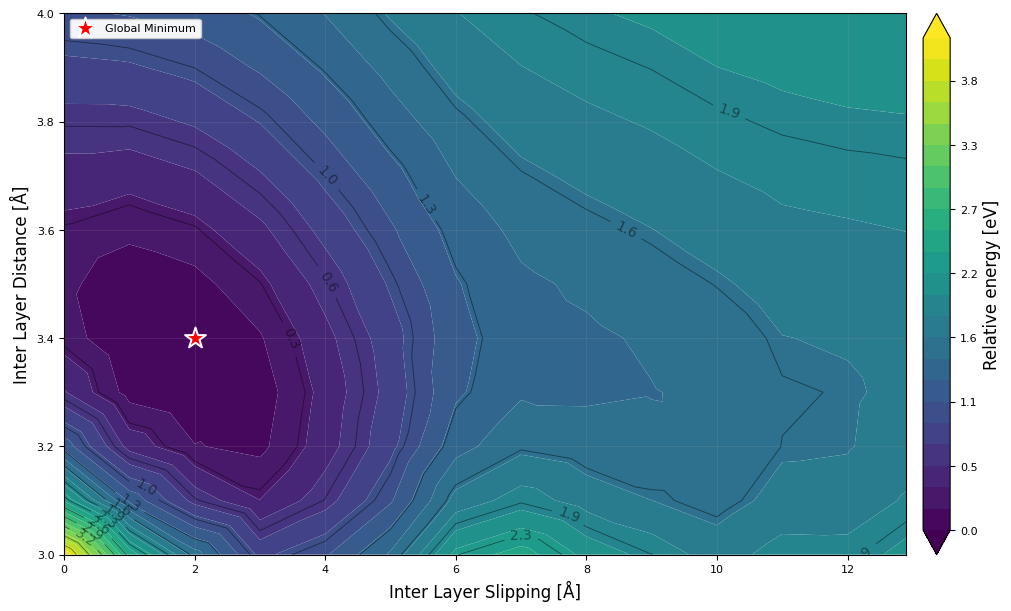

Saved: COF-LZU-1/3_COF-LZU-1_landscape/pes_COF-LZU-1_serr.png


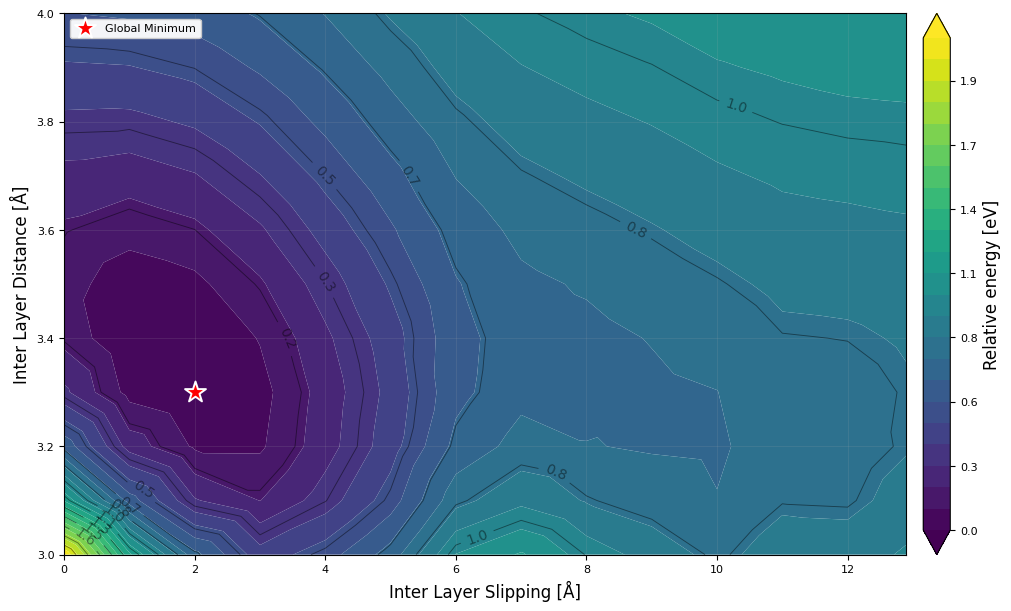

Saved: COF-LZU-1/3_COF-LZU-1_landscape/pes_COF-LZU-1_incl.png


In [9]:
landscape = cl.Landscape()
landscape.run(cof_name=COF_NAME, mode=MODE, show=True)

### Analysis & Visualization

This step analyzes optimized structures by computing interlayer distance (ILD) and interlayer slipping (ILS) from the optimized structures, and writing a summary CSV for comparison across stacking configurations.

In addition, structures can be visualized using an interactive viewer.

In [15]:
# Defaults
analyzer = cl.AnalyzeStacking()
analyzer.analyze(cof_name=COF_NAME, mode=MODE)

Serrated:
 ILD (Å)  ILS (Å)  Erel (eV)
    3.4      1.5        0.1
Inclined:
 ILD (Å)  ILS (Å)  Erel (eV)
    3.2      1.9        0.0


In [16]:
# Defaults
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(cof_name=COF_NAME, mode=MODE)

Serrated | COF-LZU-1_z34_L020_serr.cif: ILD = 3.36 Å, ILS = 1.51 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Inclined | COF-LZU-1_z33_L020_incl.cif: ILD = 3.25 Å, ILS = 1.86 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[<py3Dmol.view at 0x348487470>, <py3Dmol.view at 0x33edbc770>]

### Experimental PXRD comparison

Place exactly one experimental `.xy` file in `experimental_pxrd/`, or pass its path explicitly. The comparison generates one PDF per simulated structure in `pxrd_plots`.

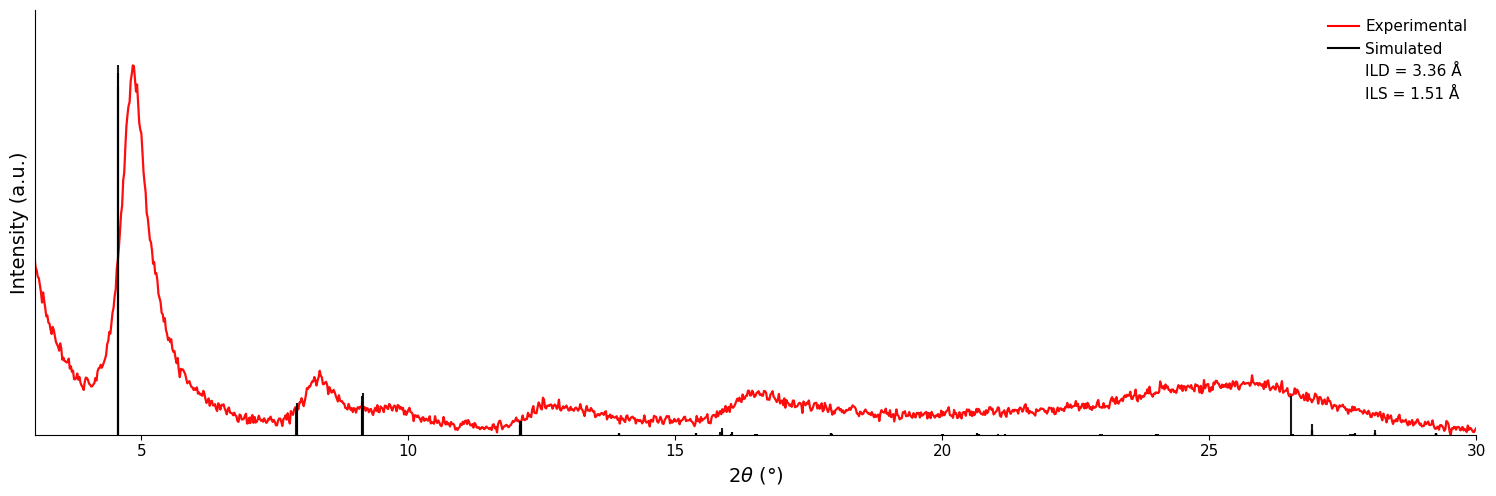

Plotted simulated and experimental PXRD pattern for COF-LZU-1_z34_L020_serr.cif


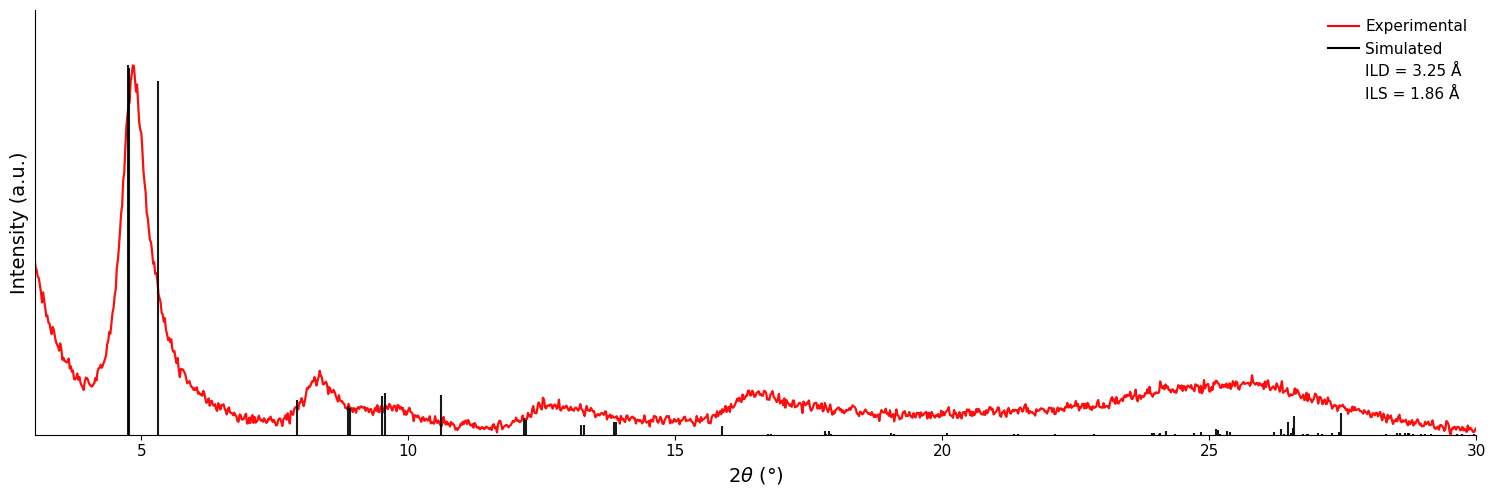

Plotted simulated and experimental PXRD pattern for COF-LZU-1_z33_L020_incl.cif


['COF-LZU-1/5_COF-LZU-1_analysis/pxrd_plots/serr/COF-LZU-1_z34_L020_serr.pdf',
 'COF-LZU-1/5_COF-LZU-1_analysis/pxrd_plots/incl/COF-LZU-1_z33_L020_incl.pdf']

In [ ]:
pxrd = cl.PXRD()
pxrd.plot_sim_vs_exp(
    cof_name=COF_NAME,
    mode=MODE,
    xlim=(3, 30),
)

## PXRD-guided refinement

The simulated and experimental PXRD patterns should first be inspected qualitatively. The refinement described below is intended for structures that already reproduce the experimental pattern reasonably well but show a **systematic offset in peak positions**. It is not intended to correct a stacking model whose simulated PXRD pattern is fundamentally inconsistent with experiment.

A consistent displacement of corresponding simulated and experimental reflections can indicate that the predicted structure is qualitatively correct while its unit-cell dimensions differ slightly from those of the experimental material. COF-Landscaper therefore provides a simple PXRD-guided refinement in which experimental diffraction peak positions are used to adjust the in-plane dimensions of the calculated structure. This follows the general principle of refining lattice dimensions against diffraction data.

If both serrated and inclined structures were evaluated above, first select the stacking mode(s) that provides the physically meaningful agreement with experiment. The comparison is performed within **user-defined 2θ regions**. Each region should contain an experimental feature and the corresponding simulated reflection that the user intends to compare.

A region is specified by its lower and upper 2θ limits:
Example:
```python

peak_regions = [
    (4.0, 5.5),
    (7.5, 9.0),
    (9.0, 10.5),
]

In [22]:
MODE = "serr"

In [23]:
peak_regions = [
    (4.0, 5.5),
    (7.5, 9),
    (9, 10.5),
    (12, 14),
    (15.5, 17.5),
    (24, 27.5),
]

pxrd.extract_peak_regions(
    cof_name=COF_NAME,
    mode=MODE,
    peak_regions=peak_regions,
)

{'COF-LZU-1_z34_L020_serr':     region  region_min  region_max source  two_theta  intensity  \
 0        1         4.0         5.5    exp   4.853669        NaN   
 1        1         4.0         5.5    sim   4.561790     97.979   
 2        1         4.0         5.5    sim   4.563480     94.140   
 3        1         4.0         5.5    sim   4.569740    100.000   
 4        2         7.5         9.0    exp   8.315781        NaN   
 5        2         7.5         9.0    sim   7.902790      7.112   
 6        2         7.5         9.0    sim   7.913650      8.564   
 7        2         7.5         9.0    sim   7.916590      7.734   
 8        3         9.0        10.5    exp   9.776081        NaN   
 9        3         9.0        10.5    sim   9.130820     10.383   
 10       3         9.0        10.5    sim   9.134220      8.835   
 11       3         9.0        10.5    sim   9.146770     11.247   
 12       4        12.0        14.0    exp  12.581022        NaN   
 13       4        12

### In-plane lattice scaling

The extracted experimental and simulated peak positions are used to estimate the in-plane lattice correction required to improve their agreement.

By default, all extracted peak regions are included (`scale_regions=None`). If some experimental features are broad, overlapping, or otherwise unsuitable for a reliable comparison, `scale_regions` can be used to restrict the scaling to selected regions.

For example, to use only regions 1, 2, and 4:

```python
scale_regions = [1, 2, 4]

In [24]:
scaled_cifs = pxrd.generate_scaled_cif(
    cof_name=COF_NAME,
    mode=MODE,
    scale_regions=[1,2],
)

### Post-optimization

The PXRD-guided scaling changes the unit-cell dimensions geometrically. The scaled structure is therefore subsequently re-optimized with MACE while keeping the refined unit cell fixed, allowing the atomic coordinates to relax within the experimentally informed cell.

In [25]:
postopt = cl.MaceOpt()
postopt.run_fixed(cof_name=COF_NAME, mode=MODE)

       Step     Time          Energy          fmax
LBFGS:    0 19:16:17   -93370.669833        4.715132
LBFGS:    1 19:16:19   -93375.980771        5.072262
LBFGS:    2 19:16:21   -93381.835846        1.643557
LBFGS:    3 19:16:23   -93382.683521        0.868263
LBFGS:    4 19:16:25   -93383.036579        0.758681
LBFGS:    5 19:16:27   -93383.191552        0.485614
LBFGS:    6 19:16:29   -93383.268659        0.297992
LBFGS:    7 19:16:31   -93383.327719        0.408955
LBFGS:    8 19:16:33   -93383.365298        0.385310
LBFGS:    9 19:16:35   -93383.391076        0.155663
LBFGS:   10 19:16:36   -93383.417576        0.283992
LBFGS:   11 19:16:38   -93383.453586        0.351876
LBFGS:   12 19:16:40   -93383.483093        0.371017
LBFGS:   13 19:16:42   -93383.503713        0.283407
LBFGS:   14 19:16:44   -93383.521748        0.194298
LBFGS:   15 19:16:45   -93383.545736        0.205664
LBFGS:   16 19:16:47   -93383.576867        0.376212
LBFGS:   17 19:16:49   -93383.606297        0.19

{'serr/COF-LZU-1_z34_L020_serr_0.9460': True}

## Postopt analysis

Repeat structural and PXRD analysis against the post-optimized structures using `source="postopt"`.

In [26]:
analyzer = cl.AnalyzeStacking()
analyzer.analyze(cof_name=COF_NAME, mode=MODE, source="postopt")

Serrated:
 ILD (Å)  ILS (Å)  Erel (eV)
    3.4      1.4         --


In [27]:
pxrd.run(cof_name=COF_NAME, mode=MODE, source="postopt")
pxrd.extract_peaks(cof_name=COF_NAME, mode=MODE, source="postopt")
pxrd.extract_peak_regions(
    cof_name=COF_NAME,
    mode=MODE,
    peak_regions=peak_regions,
    source="postopt",
)

{'COF-LZU-1_z34_L020_serr_0.9460':     region  region_min  region_max source  two_theta  intensity  \
 0        1         4.0         5.5    exp   4.853669        NaN   
 1        1         4.0         5.5    sim   4.822310     97.843   
 2        1         4.0         5.5    sim   4.824100     94.306   
 3        1         4.0         5.5    sim   4.830710    100.000   
 4        2         7.5         9.0    exp   8.315781        NaN   
 5        2         7.5         9.0    sim   8.354630      6.721   
 6        2         7.5         9.0    sim   8.366110      8.123   
 7        2         7.5         9.0    sim   8.369220      7.395   
 8        3         9.0        10.5    exp   9.776081        NaN   
 9        3         9.0        10.5    sim   9.653180      9.710   
 10       3         9.0        10.5    sim   9.656770      8.300   
 11       3         9.0        10.5    sim   9.670040     10.532   
 12       4        12.0        14.0    exp  12.581022        NaN   
 13       4   

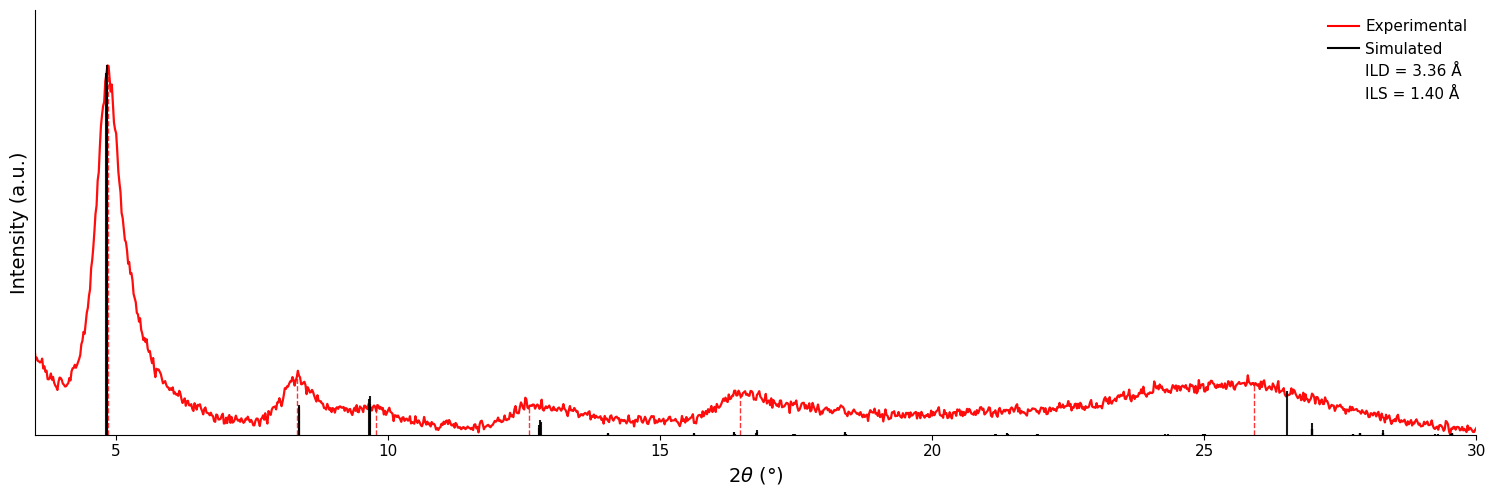

Plotted simulated and experimental PXRD pattern for COF-LZU-1_z34_L020_serr_0.9460.cif


['COF-LZU-1/7_COF-LZU-1_postanalysis/pxrd_plots/serr/COF-LZU-1_z34_L020_serr_0.9460.pdf']

In [28]:
pxrd.plot_sim_vs_exp(
    cof_name=COF_NAME,
    mode=MODE,
    source="postopt",
    xlim=(3.5, 30.0),
)

In [29]:
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(
    cof_name=COF_NAME,
    mode=MODE,
    source="postopt",
)

Serrated | COF-LZU-1_z34_L020_serr_0.9460.cif: ILD = 3.36 Å, ILS = 1.40 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.